# RNNs with PyTorch — Character-Level Language Model

An RNN processes a sequence one step at a time, maintaining a **hidden state** that summarises past context: `h_t = f(x_t, h_{t-1})`.

**Corpus**: *Alice's Adventures in Wonderland* (Lewis Carroll, 1865) via NLTK Gutenberg.

We train a character-level model: given the last 100 characters, predict the next one. After training we can generate new text by feeding predictions back as input.

**(SOLUTION)**

## Key Concept: Sequential Processing & the Vanishing Gradient Problem

An RNN processes one token at a time, updating its hidden state:
```
h_t = tanh(W_h · h_{t-1} + W_x · x_t + b)
```

**Why sequential processing is a problem:**
Positions in a sequence *must* be computed in order — you can't parallelise
across time. On modern GPUs that excel at parallel computation, this is a
fundamental throughput bottleneck.

**The vanishing gradient problem:**
During backpropagation through time (BPTT), gradients travel back through
every timestep. Each step multiplies by `W_h` and by `tanh'(·) ≤ 1`:

```
∂L/∂h₁  ≈  (W_h)^(T-1) · (product of tanh derivatives)
```

For a 100-step sequence, if the spectral radius of `W_h < 1`, this product
shrinks exponentially → the model cannot learn long-range dependencies.
If `‖W_h‖ > 1`, gradients *explode* → training destabilises.

**Gradient clipping** (Step 6) patches the exploding case.
**LSTMs** (Lesson 5) address the vanishing case with a gated cell state.


## Step 1: Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from nltk.corpus import gutenberg
import matplotlib.pyplot as plt

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

device: mps


## Key Concept: Devices and `.to(device)`

PyTorch can run computations on the **CPU** or a **GPU** (NVIDIA CUDA or
Apple Silicon MPS). Moving a tensor or model to a device means its data and
computations live there.

```python
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')

model = MyModel().to(device)   # moves all weight tensors to device
X = X.to(device)               # moves input data to the same device
```

**Rule:** model and data must be on the *same* device — mixing them raises
a `RuntimeError`. Call `.to(device)` on both.

> 📖 [PyTorch — CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)


## Key Concept: `Dataset` and `DataLoader`

`DataLoader` handles batching, shuffling, and parallel data loading so your
training loop stays simple.

```python
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train, y_train)   # pairs inputs with labels
loader  = DataLoader(dataset,
                     batch_size=64,
                     shuffle=True)           # reshuffles every epoch

for Xb, yb in loader:                       # Xb: (64, ...) one mini-batch
    ...
```

Key parameters:
- `batch_size` — number of samples per gradient update
- `shuffle=True` — randomise order each epoch (always use for training)
- `num_workers` — background processes for loading (set to 2-4 on most machines)

> 📖 [PyTorch — Writing a Custom Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)


## Step 2: Load and Inspect the Corpus

In [2]:
text = gutenberg.raw('carroll-alice.txt')[:80000]

char2idx  = {ch: i for i, ch in enumerate(sorted(set(text)))}
idx2char  = {i: ch for ch, i in char2idx.items()}
vocab_size = len(char2idx)

print(f'Characters : {len(text):,}')
print(f'Vocab size : {vocab_size}')
print(f'Sample     : {text[:120]!r}')

Characters : 80,000
Vocab size : 72
Sample     : "[Alice's Adventures in Wonderland by Lewis Carroll 1865]\n\nCHAPTER I. Down the Rabbit-Hole\n\nAlice was beginning to get ve"


## Step 3: Create Training Sequences

In [3]:
SEQ_LEN = 100  # each sample = 100 chars; longer = more context but slower
STRIDE  = 5    # slide window by 5 chars → lots of overlapping samples for training

data   = [char2idx[c] for c in text]  # encode entire text as integer indices
# X_seqs[i] = chars at positions i through i+99
# y_seqs[i] = X_seqs[i] shifted right by 1 — the target at every step is the next char
X_seqs = [data[i:i+SEQ_LEN]   for i in range(0, len(data)-SEQ_LEN-1, STRIDE)]
y_seqs = [data[i+1:i+SEQ_LEN+1] for i in range(0, len(data)-SEQ_LEN-1, STRIDE)]

# X_tensor: (num_seqs, 100) — dtype=long required by nn.Embedding
# y_tensor: (num_seqs, 100) — dtype=long required by CrossEntropyLoss
X_tensor = torch.tensor(X_seqs, dtype=torch.long)
y_tensor = torch.tensor(y_seqs, dtype=torch.long)
print(f'Sequences: {len(X_seqs):,}  X:{X_tensor.shape}  y:{y_tensor.shape}')

Sequences: 15,980  X:torch.Size([15980, 100])  y:torch.Size([15980, 100])


## Key Concept: Sequences, Batches, and Loss — A Complete Walkthrough

This section traces one training batch from raw text all the way to a loss number.
Understanding it makes the training loop code read like English.

---

### Step 1 — Raw text becomes integer indices

Every character in the corpus gets a unique integer ID, built by sorting all unique characters.
For *Alice in Wonderland*:

```
'\n' → 0     ' ' → 1     '!' → 2     ...   'A' → 8     'a' → 35
```

The full 80 000-character corpus becomes a flat list of integers:

```
text:    [ A    l    i    c    e    _    w    a    s   … ]
indices: [ 8    47   45   39   41   1    63   35   55  … ]
                                        ↑
                                        '_' represents a space character
```

`vocab_size` (**V** ≈ 75) is the number of unique characters in the corpus.

---

### Step 2 — Sliding windows create training sequences

The corpus is sliced into overlapping windows of length `SEQ_LEN` (**L = 100**):

```
Full text (80 000 chars):  A l i c e   w a s   b e g i n n i n g   t o …

Window 0 — input  X[0]: chars 0–99    "Alice was beg…"   (100 chars)
           target y[0]: chars 1–100   "lice was begi…"   (100 chars)

Window 1 (stride = 5, so starts 5 chars later):
           input  X[1]: chars 5–104
           target y[1]: chars 6–105
```

`y[i]` is `X[i]` shifted right by one character. At every position `t`,
the task is: **"given all characters seen so far, predict the next one."**

---

### Step 3 — What `Xb` and `yb` are in the training loop

The DataLoader groups windows into batches. Key variables:

| Variable | Shape | Meaning |
|---|---|---|
| **B** | scalar = 128 | **batch size** — sequences processed together per weight update |
| **L** | scalar = 100 | **sequence length** = `SEQ_LEN` |
| **V** | scalar ≈ 75 | **vocab size** — number of unique characters |
| `Xb` | `(B, L)` = `(128, 100)` | integer character indices — the *inputs* |
| `yb` | `(B, L)` = `(128, 100)` | integer character indices — the *targets* (next chars) |

One concrete row of the batch:

```
Xb[0]:  [ 8,  47,  45,  39,  41,   1,  63,  35,  55, … ]   ← "Alice was…"
yb[0]:  [ 47,  45,  39,  41,   1,  63,  35,  55,  42, … ]   ← "lice was …" (shifted right by 1)
          ↑
          position 0: input = 'A' (index 8),  target = 'l' (index 47)
          position 1: input = 'l' (index 47), target = 'i' (index 45)
```

**Why batch size 128 (B = 128)?** Processing 128 sequences at once averages gradients
across 128 examples before each weight update — more stable than one at a time, and
GPUs are built to execute many matrix operations in parallel.

---

### Step 4 — What `model(Xb)` does, layer by layer

`CharRNN` has three stacked components. Here is what each does to the data:

```
Xb                              shape (B, L) = (128, 100)

  │
  ▼  nn.Embedding(V=75, embed_dim=64)
     Replaces each integer index with a learned 64-dimensional vector.
     'A' (index 8)  →  [ 0.12, -0.34,  0.78, …]   (64 numbers, learned during training)
     'l' (index 47) →  [-0.09,  0.61, -0.22, …]   (64 different numbers)
     Raw integers have no geometric meaning; these vectors give the model something
     to work with algebraically.

after embedding                 shape (B, L, 64) = (128, 100, 64)

  │
  ▼  nn.RNN(input_size=64, hidden_size=256, num_layers=2)
     Reads the sequence left-to-right. At each position t:
       h_t = tanh( W_input · embed[t]  +  W_hidden · h_{t−1} )
     h_{t−1} is the "memory" of everything seen before position t.
     Two stacked layers refine the representation further.

after RNN                       shape (B, L, 256) = (128, 100, 256)
                                ← 256-dimensional context vector at every position

  │
  ▼  nn.Linear(256, V=75)
     Maps each 256-d context vector to V=75 raw scores — one per possible next character.
     The same weight matrix is applied independently at every position.

logits                          shape (B, L, V) = (128, 100, 75)
```

`logits[b, t, c]` is the model's raw score for character `c` being the next
character after position `t` in sequence `b`. These are called **logits** because
they are the raw input *to* softmax — they are unbounded and do not sum to 1.

Concretely, `logits[0, 0, :]` after seeing only 'A':

```
index  0 ('\n') : -1.3    ← model thinks this is unlikely
index  1 (' ')  :  2.1    ← plausible
…
index 47 ('l')  :  3.8    ← model's top guess (correct answer is index 47)
…
index 74 ('z')  : -0.9    ← model thinks this is unlikely
```

At the start of training the logits are nearly random. After training,
the correct character gets the highest score.

---

### Step 5 — Computing the loss

`CrossEntropyLoss` requires:
- predictions: 2-D tensor of shape `(N, V)` — N examples, V classes
- targets: 1-D tensor of shape `(N,)` — one correct class index per example

Our `logits` are 3-D: shape `(B, L, V) = (128, 100, 75)`. We have
`B × L = 128 × 100 = 12 800` separate prediction problems, so we flatten first:

```python
logits.view(-1, vocab_size)   # (128, 100, 75) → (12 800, 75)
yb.view(-1)                   # (128, 100)     → (12 800,)
```

For each of the 12 800 positions, `CrossEntropyLoss`:
1. Applies softmax to the V=75 logits → 75 probabilities that sum to 1
2. Looks up the probability given to the **correct** next character
3. Computes `−log( P(correct character) )` — a low probability → large loss

The final loss is the **mean** over all 12 800 positions.

**Expected loss values:**
- Start of training: model guesses randomly → P ≈ 1/75 → loss ≈ −log(1/75) ≈ **4.3**
- Well-trained model: concentrates probability on right characters → loss < **1.5**

> **Perplexity** = exp(loss). A perplexity of 75 means the model is as uncertain as if
> choosing uniformly over all 75 characters. A well-trained model reaches perplexity < 5.


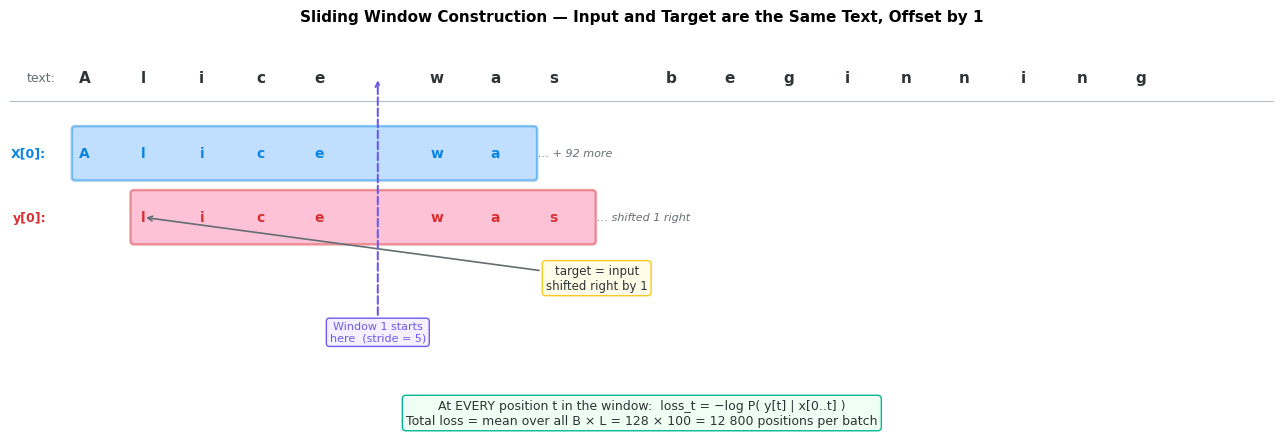

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.set_xlim(-0.5, 13.5)
ax.set_ylim(-0.5, 4.5)
ax.axis("off")
ax.set_title(
    "Sliding Window Construction — Input and Target are the Same Text, Offset by 1",
    fontsize=11, fontweight="bold",
)

# ── Text strip ─────────────────────────────────────────────────────────────────
snippet  = list("Alice was beginning")
n        = len(snippet)
char_w   = 13.0 / (n + 1)

for j, ch in enumerate(snippet):
    x = (j + 0.5) * char_w
    ax.text(x, 3.9, ch, ha="center", va="center", fontsize=11,
            fontweight="bold", color="#2d3436")

ax.text(0.0, 3.9, "text:", ha="right", va="center", fontsize=9, color="#636e72")
ax.axhline(3.6, color="#b2bec3", lw=0.8)

# ── Window 0 band ─────────────────────────────────────────────────────────────
w0_chars = 8   # show 8 chars of the 100-char window
x0_start = 0.5 * char_w - 0.1
x0_end   = (w0_chars + 0.0) * char_w + 0.1

r_x = mpatches.FancyBboxPatch(
    (x0_start, 2.65), x0_end - x0_start, 0.6,
    boxstyle="round,pad=0.04", fc="#74b9ff", ec="#0984e3", lw=1.8, alpha=0.45, zorder=1,
)
ax.add_patch(r_x)
ax.text(-0.1, 2.95, "X[0]:", ha="right", va="center", fontsize=9,
        color="#0984e3", fontweight="bold")
ax.text(x0_end + 0.05, 2.95, "… + 92 more", ha="left", va="center",
        fontsize=8, color="#636e72", style="italic")

r_y = mpatches.FancyBboxPatch(
    (1.5 * char_w - 0.1, 1.85), x0_end - x0_start, 0.6,
    boxstyle="round,pad=0.04", fc="#fd79a8", ec="#d63031", lw=1.8, alpha=0.45, zorder=1,
)
ax.add_patch(r_y)
ax.text(-0.1, 2.15, "y[0]:", ha="right", va="center", fontsize=9,
        color="#d63031", fontweight="bold")
ax.text(x0_end + 0.05 + char_w, 2.15, "… shifted 1 right", ha="left",
        va="center", fontsize=8, color="#636e72", style="italic")

# ── Character labels for X and y rows ─────────────────────────────────────────
for j, ch in enumerate(snippet[:w0_chars]):
    ax.text((j + 0.5) * char_w, 2.95, ch, ha="center", va="center",
            fontsize=10, fontweight="bold", color="#0984e3")
for j, ch in enumerate(snippet[1:w0_chars + 1]):
    ax.text((j + 1.5) * char_w, 2.15, ch, ha="center", va="center",
            fontsize=10, fontweight="bold", color="#d63031")

# ── Offset arrow ──────────────────────────────────────────────────────────────
ax.annotate(
    "target = input\nshifted right by 1",
    xy=(1.5 * char_w, 2.15), xytext=(6.0, 1.25),
    fontsize=8.5, ha="center", color="#2d3436",
    arrowprops=dict(arrowstyle="->", color="#636e72", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", fc="#fffde7", ec="#f9ca24", lw=1),
)

# ── Window 1 marker (stride=5) ────────────────────────────────────────────────
ax.annotate(
    "Window 1 starts\nhere  (stride = 5)",
    xy=(5.5 * char_w, 3.9), xytext=(5.5 * char_w, 0.6),
    fontsize=8, ha="center", color="#6c5ce7",
    arrowprops=dict(arrowstyle="->", color="#6c5ce7", lw=1.5, linestyle="dashed"),
    bbox=dict(boxstyle="round,pad=0.3", fc="#f5f0ff", ec="#6c5ce7", lw=1),
)

# ── Bottom summary ────────────────────────────────────────────────────────────
ax.text(
    6.5, -0.3,
    "At EVERY position t in the window:  loss_t = −log P( y[t] | x[0..t] )\n"
    "Total loss = mean over all B × L = 128 × 100 = 12 800 positions per batch",
    ha="center", va="center", fontsize=9, color="#2d3436",
    bbox=dict(boxstyle="round,pad=0.3", fc="#f0fff4", ec="#00b894", lw=1),
)

plt.tight_layout()
plt.show()


## Step 4: DataLoader

In [5]:
# Each batch: Xb (128, 100) char sequences, yb (128, 100) target sequences
# shuffle=True is safe — temporal order is preserved *within* each 100-char sequence
train_loader = DataLoader(
    TensorDataset(X_tensor, y_tensor),
    batch_size=128, shuffle=True
)
print(f'Batches per epoch: {len(train_loader)}')

Batches per epoch: 125


## Step 5: Define the RNN Model

In [6]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=256, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        # Embedding: (vocab_size, 64) lookup table; (B,L) → (B,L,64)
        self.embedding   = nn.Embedding(vocab_size, embed_dim)
        # RNN: reads 64-d input, maintains 256-d hidden state, 2 stacked layers
        # output: (B, L, 256)  hidden h: (num_layers, B, 256)
        self.rnn         = nn.RNN(embed_dim, hidden_size, num_layers,
                                  batch_first=True, dropout=0.3)
        # fc maps each timestep's hidden state to a distribution over all characters
        self.fc          = nn.Linear(hidden_size, vocab_size)  # (B,L,256)→(B,L,vocab_size)

    def forward(self, x, hidden=None):    # x: (B, L) char indices
        x      = self.embedding(x)         # → (B, L, 64)
        out, h = self.rnn(x, hidden)       # out: (B,L,256)  h: (num_layers,B,256)
        return self.fc(out), h             # logits: (B, L, vocab_size)

    def init_hidden(self, batch_size, device):
        # one hidden vector per layer per sample in the batch
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

model = CharRNN(vocab_size).to(device)
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))

CharRNN(
  (embedding): Embedding(72, 64)
  (rnn): RNN(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=72, bias=True)
)
Parameters: 237128


### Concept Check: RNN Mechanics — Answers

**Q1.** `init_hidden` creates a zero tensor of shape
`(num_layers, batch_size, hidden_size)`. What does each dimension represent?
Why is the initial hidden state zeros rather than, say, random noise?

**→** Dimensions: `num_layers` (one hidden vector per stacked layer),
`batch_size` (one state per sequence in the batch), `hidden_size` (the
hidden representation dimension).
Zeros is a neutral starting point — the model has seen nothing yet.
Random initialisation would inject noise-dependent signals into the first
few predictions, making training less stable and the results batch-order
dependent.

**Q2.** The embedding converts character indices `(B, L)` → `(B, L, 64)`.
Compare this to one-hot encoding `(B, L, vocab_size)`. What are the two
key advantages of learned embeddings for a character-level model?

**→** (a) **Dimensionality**: 64-d embedding vs. 75-d one-hot (roughly
the vocab size) — not a huge saving here, but for word-level models with
50 000-token vocabularies the saving is massive.
(b) **Semantic proximity**: learned embeddings cluster similar characters
together (e.g., upper/lower case pairs, vowels). One-hot vectors are
orthogonal — 'a' and 'A' are maximally dissimilar — losing that structure.

**Q3.** Can two different sequences in the same batch be processed in parallel?
Can two *timesteps* within the same sequence be processed in parallel?
What does this imply for GPU utilisation on long sequences?

**→** Different batch sequences *can* be processed in parallel (matrix
ops over the batch dimension are independent). Timesteps within one sequence
*cannot* — each `h_t` depends on `h_{t-1}`. This means the GPU must execute
`L` sequential matrix multiplications no matter how large the batch.
For L=100, that's 100 sequential steps — a fundamental serial bottleneck.

## Key Concept: Backpropagation Through Time (BPTT)

Lesson 01 built backprop manually for a 2-layer network. For an RNN the same
mechanics apply, but the computational graph is **L steps deep**
(here **L** = `SEQ_LEN` = 100 — one node per character). PyTorch's autograd builds this graph silently
during the forward pass; `loss.backward()` unrolls it all.

### The unrolled computation graph

```
x_0 ──▶ [RNN] ──▶ h_0 ──▶ [RNN] ──▶ h_1 ──▶ ··· ──▶ h_{L-1}
                    │                  │                   │
               prediction_0      prediction_1        prediction_{L-1}
                    │                  │                   │
                   L_0                L_1               L_{L-1}
```

**Total loss** = average cross-entropy across all L positions in each of the B sequences in the batch
(**B** = batch size, **L** = sequence length — both defined in the Key Concept cell above).

### What loss.backward() actually does

1. Computes the prediction error at each timestep.
2. Propagates the error *backwards through time* — from step L-1 back to step 0.
3. Accumulates gradients for `W_h` and `W_x` (the **same weights are reused
   at every step**, so they receive contributions from all L steps at once).

This repeated reuse of weights across many steps is what makes RNN training
tricky: gradients can **explode** (become huge) or **vanish** (become zero)
as they travel back through 100 steps. That's why:
- **Gradient clipping** (`clip_grad_norm_`) is not optional — it rescales the
  gradient vector *after* `loss.backward()` but *before* `optimizer.step()`.
- **LSTMs** were invented to address the vanishing side of this problem.
- **Transformers** sidestep it entirely by replacing the sequential chain with
  direct attention connections between any two positions.

### Truncated BPTT — what this code already does

```python
logits, _ = model(Xb)   # ← _ discards h_n (the final hidden state)
```

> **Logits** = the raw, un-normalized scores the model produces *before*
> applying softmax. Think of them as "how confident the model is about each
> character" before those confidences are turned into probabilities.

Each batch starts with a fresh hidden state (zeros). Discarding `h_n`
**severs the gradient graph at every batch boundary** — the backward pass is
truncated to at most `SEQ_LEN = 100` steps per batch. Passing `h_n` forward
would require gradients to flow through the entire training corpus, which is
impractical.

### The loss reshape

```python
loss = criterion(
    logits.view(-1, vocab_size),   # (B, L, V)  →  (B*L, V)
    yb.view(-1)                    # (B, L)      →  (B*L,)
)
```

`CrossEntropyLoss` expects a 2-D input. Flattening the batch and time dimensions
together lets it compute **one loss value per character**, averaged across all
`B × L` positions — i.e., the model is supervised at every single timestep.

> 📖 **Further reading:**
> - [Karpathy — The Unreasonable Effectiveness of RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
> - [Colah — Understanding LSTMs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)


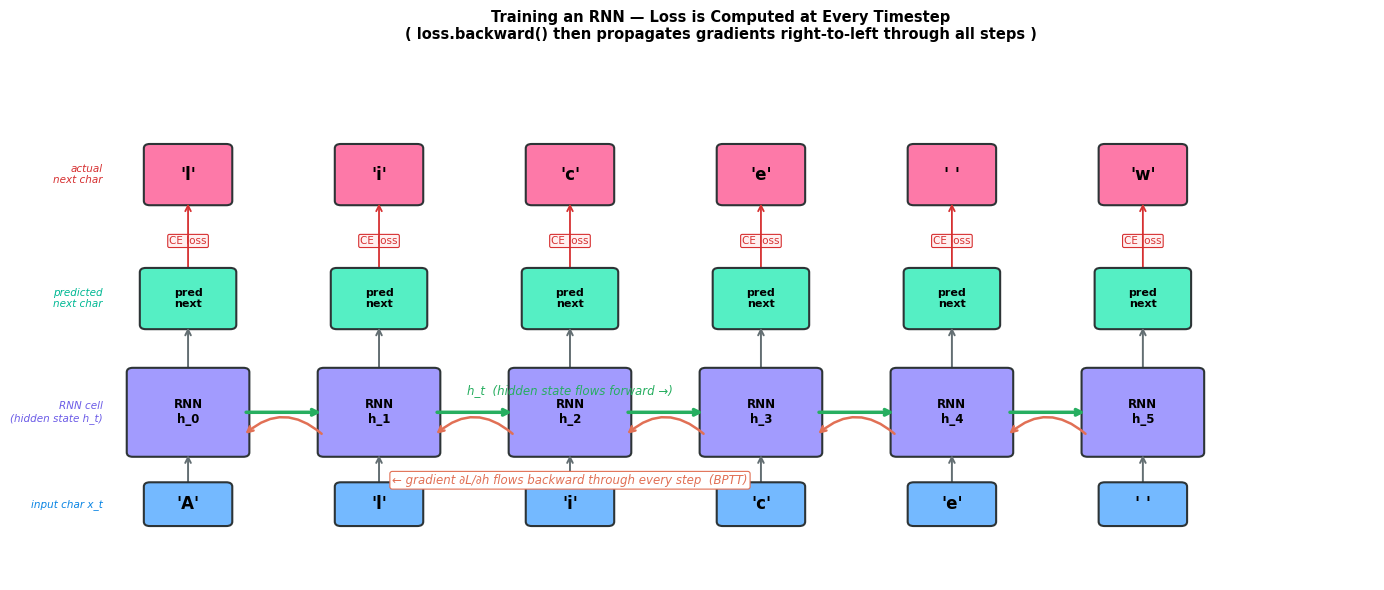

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Six timesteps pulled from the start of Alice in Wonderland
chars_in  = ["A",   "l",   "i",   "c",   "e",   " "]   # x_0 … x_5
chars_out = ["l",   "i",   "c",   "e",   " ",   "w"]   # actual next chars

xs = [1.2 + i * 1.9 for i in range(6)]   # evenly spaced columns

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 13)
ax.set_ylim(-0.8, 6.5)
ax.axis("off")
ax.set_title(
    "Training an RNN — Loss is Computed at Every Timestep\n"
    "( loss.backward() then propagates gradients right-to-left through all steps )",
    fontsize=10.5, fontweight="bold",
)

for i, (x, ch_in, ch_out) in enumerate(zip(xs, chars_in, chars_out)):

    # ── Row 1 (top): actual next character (target) ──────────────────────────
    r_tgt = mpatches.FancyBboxPatch(
        (x - 0.38, 4.4), 0.76, 0.72,
        boxstyle="round,pad=0.06", fc="#fd79a8", ec="#2d3436", lw=1.5, zorder=3,
    )
    ax.add_patch(r_tgt)
    ax.text(x, 4.76, f"'{ch_out}'", ha="center", va="center",
            fontsize=12, fontweight="bold")

    # ── Loss annotation ───────────────────────────────────────────────────────
    ax.text(x, 3.85, "CE loss", ha="center", va="center",
            fontsize=7.5, color="#d63031",
            bbox=dict(boxstyle="round,pad=0.15", fc="#fff0f0", ec="#d63031", lw=0.8))

    # Arrow: predicted → CE loss ↑ actual
    ax.annotate("", xy=(x, 4.4), xytext=(x, 3.4),
                arrowprops=dict(arrowstyle="->", color="#d63031", lw=1.3, zorder=4))

    # ── Row 2: "predicted next char" (output of RNN at this step) ─────────────
    r_pred = mpatches.FancyBboxPatch(
        (x - 0.42, 2.7), 0.84, 0.72,
        boxstyle="round,pad=0.06", fc="#55efc4", ec="#2d3436", lw=1.5, zorder=3,
    )
    ax.add_patch(r_pred)
    ax.text(x, 3.06, "pred\nnext", ha="center", va="center",
            fontsize=8, fontweight="bold")

    # Arrow: RNN → prediction
    ax.annotate("", xy=(x, 2.7), xytext=(x, 2.05),
                arrowprops=dict(arrowstyle="->", color="#636e72", lw=1.4, zorder=4))

    # ── Row 3: RNN cell (hidden state) ───────────────────────────────────────
    r_rnn = mpatches.FancyBboxPatch(
        (x - 0.55, 0.95), 1.1, 1.1,
        boxstyle="round,pad=0.06", fc="#a29bfe", ec="#2d3436", lw=1.5, zorder=3,
    )
    ax.add_patch(r_rnn)
    ax.text(x, 1.5, f"RNN\nh_{i}", ha="center", va="center",
            fontsize=8.5, fontweight="bold")

    # Arrow: x_t → RNN
    ax.annotate("", xy=(x, 0.95), xytext=(x, 0.48),
                arrowprops=dict(arrowstyle="->", color="#636e72", lw=1.4, zorder=4))

    # ── Row 4 (bottom): input character ──────────────────────────────────────
    r_in = mpatches.FancyBboxPatch(
        (x - 0.38, 0.0), 0.76, 0.48,
        boxstyle="round,pad=0.06", fc="#74b9ff", ec="#2d3436", lw=1.5, zorder=3,
    )
    ax.add_patch(r_in)
    ax.text(x, 0.24, f"'{ch_in}'", ha="center", va="center",
            fontsize=12, fontweight="bold")

# ── Hidden state arrows (green, forward: left → right) ───────────────────────
for i in range(len(xs) - 1):
    ax.annotate(
        "", xy=(xs[i + 1] - 0.55, 1.5), xytext=(xs[i] + 0.55, 1.5),
        arrowprops=dict(arrowstyle="->", color="#27ae60", lw=2.5, zorder=5),
    )
ax.text(xs[2], 1.75, "h_t  (hidden state flows forward →)", ha="center",
        fontsize=8.5, color="#27ae60", style="italic")

# ── BPTT gradient arrows (red, backward: right → left, curved) ───────────────
for i in range(len(xs) - 1, 0, -1):
    ax.annotate(
        "", xy=(xs[i - 1] + 0.55, 1.18), xytext=(xs[i] - 0.55, 1.18),
        arrowprops=dict(
            arrowstyle="->", color="#e17055", lw=1.8,
            connectionstyle="arc3,rad=0.45", zorder=2,
        ),
    )
ax.text(xs[2], 0.52, "← gradient ∂L/∂h flows backward through every step  (BPTT)",
        ha="center", fontsize=8.5, color="#e17055", style="italic",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#e17055", lw=0.8))

# ── Row labels on the left ────────────────────────────────────────────────────
for y, label, color in [
    (4.76, "actual\nnext char",  "#d63031"),
    (3.06, "predicted\nnext char", "#00b894"),
    (1.50, "RNN cell\n(hidden state h_t)", "#6c5ce7"),
    (0.24, "input char x_t", "#0984e3"),
]:
    ax.text(0.35, y, label, ha="right", va="center", fontsize=7.5,
            color=color, style="italic")

plt.tight_layout()
plt.show()


## Step 6: Training Loop

In [8]:
criterion   = nn.CrossEntropyLoss()
optimizer   = optim.Adam(model.parameters(), lr=0.002)
epoch_losses = []

for epoch in range(30):
    model.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)    # Xb: (128,100)  yb: (128,100)

        # Forward pass. model() returns (logits, h_n); we discard h_n with _.
        # Discarding h_n is TRUNCATED BPTT: the next batch starts with a zero
        # hidden state, so gradients don't flow across batch boundaries.
        logits, _ = model(Xb)   # logits: (128, 100, vocab_size)

        # CrossEntropyLoss needs (N, C) logits and (N,) integer targets.
        # view(-1, vocab_size) collapses batch AND time: (128×100, vocab_size)
        # yb.view(-1) does the same for targets: (128×100,)
        # Result: one loss term per character position across the whole batch.
        loss = criterion(logits.view(-1, vocab_size), yb.view(-1))

        optimizer.zero_grad()
        loss.backward()

        # RNN gradients can explode over 100 timesteps. Clipping rescales the
        # entire gradient vector to have L2-norm ≤ 1.0 *before* the weight update.
        # This keeps the update step bounded without changing gradient direction.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        total_loss += loss.item()
    avg = total_loss / len(train_loader)
    epoch_losses.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:2d} | Loss: {avg:.4f}')


Epoch  5 | Loss: 1.0861


Epoch 10 | Loss: 0.8305


Epoch 15 | Loss: 0.7422


Epoch 20 | Loss: 0.6956


Epoch 25 | Loss: 0.6635


Epoch 30 | Loss: 0.6418


### Concept Check: Training Stability & Text Generation — Answers

**Q1.** `clip_grad_norm_(model.parameters(), 1.0)` rescales the gradient
vector so its L2 norm is at most 1.0. Why doesn't clipping cause
the vanishing gradient problem (as opposed to the exploding problem)?

**→** Clipping rescales gradients *down* when they are too large, but
does not change their direction. Vanishing gradients are already small —
clipping never touches them (their norm is already < 1). The two problems
are on opposite ends of the magnitude spectrum. Gradient clipping only
intervenes when `‖grad‖ > max_norm`.

**Q2.** Temperature sampling: dividing logits by `T` before softmax.
- `T → 0`: what does the distribution become?
- `T → ∞`: what does the distribution become?
- Why is `T = 1.0` the "unmodified" distribution?

**→** - `T → 0`: the distribution becomes a **one-hot** (argmax) — the model
  always picks the highest-probability character. Output is deterministic
  and often repetitive.
- `T → ∞`: logits/T → 0 → softmax → **uniform** distribution — the model
  picks characters at random, ignoring what it learned.
- `T = 1.0`: logits are passed unchanged to softmax — the model's learned
  distribution, unmodified.

## Step 7: Generate Text

In [9]:
def generate(model, seed_text, char2idx, idx2char, length=400,
             temperature=0.8, device='cpu'):
    model.eval()
    with torch.no_grad():
        hidden = model.init_hidden(1, device)  # (2, 1, 256) — batch_size=1
        # Feed seed chars to build a meaningful hidden state before generating
        for ch in seed_text[:-1]:
            x = torch.tensor([[char2idx.get(ch, 0)]], dtype=torch.long, device=device)  # (1,1)
            _, hidden = model(x, hidden)  # discard logits, keep updated hidden state
        result  = seed_text
        current = seed_text[-1]
        for _ in range(length):
            x = torch.tensor([[char2idx.get(current, 0)]], dtype=torch.long, device=device)  # (1,1)
            logits, hidden = model(x, hidden)   # logits: (1, 1, vocab_size)
            # squeeze → (vocab_size,); divide by temperature to sharpen or soften distribution
            probs  = torch.softmax(logits.squeeze() / temperature, dim=0)
            next_i = torch.multinomial(probs, 1).item()  # sample (not argmax) for variety
            current = idx2char[next_i]
            result += current
    return result

print(generate(model, 'Alice ', char2idx, idx2char, 400, 0.8, str(device)))

Alice thought was the Dormouse shook the things I know
who I am
          nowning, so she went on in the directly.

'Please did not her in any of them--and the other: she had been raubout, somenody, in a solrowful
on its head impatiently, 'in any off of the goos--(how I was, that the day of at the sky about her and back to the teams to do it!
Oh! So Bhe fall mose so much more, and one for the first voic


## Step 8: Experiment with Temperature

In [10]:
print('=== temperature=0.5 (focused) ===')
print(generate(model, 'The ', char2idx, idx2char, 200, 0.5, str(device)))

print('\n=== temperature=1.2 (creative) ===')
print(generate(model, 'The ', char2idx, idx2char, 200, 1.2, str(device)))

=== temperature=0.5 (focused) ===


The poor little thing howling to itselas smalled over the little door:
but, alas! the little house, and have no nothing buck as she sat
down and began to cry again.

'You might just as well say
that "I se

=== temperature=1.2 (creative) ===


The once it had looked up, and we hastily letting ever was!
Wells there's hard: and did not under the bottle ohe crachiculy,
''outhed along.

'Aup about eppebs, who with some
non take. 'Don's such
a dreas


## Step 9: Visualize the RNN Architecture

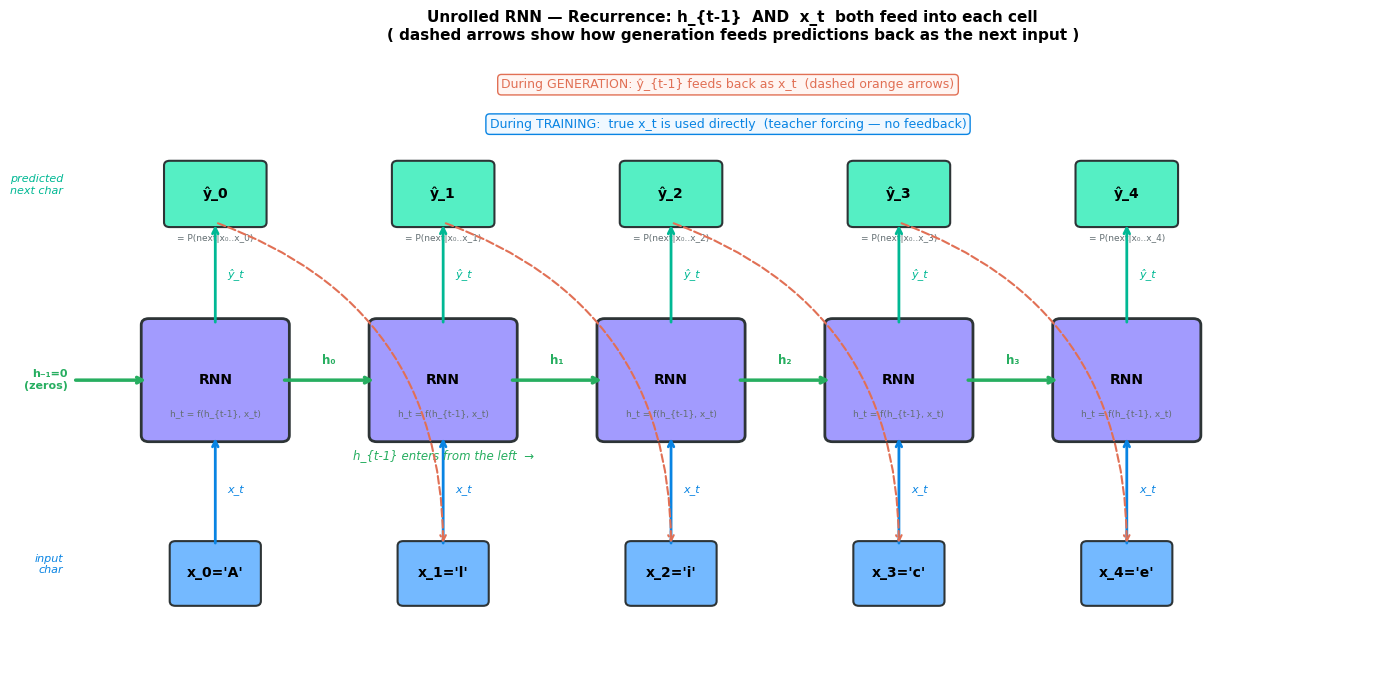

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

chars   = ["A",  "l",  "i",  "c",  "e"]
h_label = ["h₋₁=0", "h₀", "h₁", "h₂", "h₃"]   # hidden state names

xs = [i * 2.4 + 1.2 for i in range(5)]

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(-0.2, 13.5)
ax.set_ylim(-0.5, 7.5)
ax.axis("off")
ax.set_title(
    "Unrolled RNN — Recurrence: h_{t-1}  AND  x_t  both feed into each cell\n"
    "( dashed arrows show how generation feeds predictions back as the next input )",
    fontsize=11, fontweight="bold",
)

for i, (x, ch) in enumerate(zip(xs, chars)):

    # ── RNN cell ──────────────────────────────────────────────────────────────
    r = mpatches.FancyBboxPatch(
        (x - 0.7, 2.6), 1.4, 1.4,
        boxstyle="round,pad=0.08", fc="#a29bfe", ec="#2d3436", lw=2, zorder=3,
    )
    ax.add_patch(r)
    ax.text(x, 3.3, f"RNN", ha="center", va="center", fontsize=10, fontweight="bold")
    ax.text(x, 2.88, "h_t = f(h_{t-1}, x_t)", ha="center", va="center",
            fontsize=6.5, color="#636e72")

    # ── Input character (below) ───────────────────────────────────────────────
    r_in = mpatches.FancyBboxPatch(
        (x - 0.42, 0.5), 0.84, 0.7,
        boxstyle="round,pad=0.06", fc="#74b9ff", ec="#2d3436", lw=1.5, zorder=3,
    )
    ax.add_patch(r_in)
    ax.text(x, 0.85, f"x_{i}='{ch}'", ha="center", va="center",
            fontsize=10, fontweight="bold")

    # Arrow: x_t → RNN (from below)
    ax.annotate("", xy=(x, 2.6), xytext=(x, 1.2),
                arrowprops=dict(arrowstyle="->", color="#0984e3", lw=2, zorder=4))
    ax.text(x + 0.13, 1.9, "x_t", ha="left", va="center",
            fontsize=8, color="#0984e3", style="italic")

    # ── Predicted next char (above) ───────────────────────────────────────────
    r_pred = mpatches.FancyBboxPatch(
        (x - 0.48, 5.3), 0.96, 0.72,
        boxstyle="round,pad=0.06", fc="#55efc4", ec="#2d3436", lw=1.5, zorder=3,
    )
    ax.add_patch(r_pred)
    ax.text(x, 5.66, f"ŷ_{i}", ha="center", va="center",
            fontsize=10, fontweight="bold")
    ax.text(x, 5.1, f"= P(next|x₀..x_{i})", ha="center", va="center",
            fontsize=6.5, color="#636e72")

    # Arrow: RNN → prediction (upward)
    ax.annotate("", xy=(x, 5.3), xytext=(x, 4.0),
                arrowprops=dict(arrowstyle="->", color="#00b894", lw=2, zorder=4))
    ax.text(x + 0.13, 4.65, "ŷ_t", ha="left", va="center",
            fontsize=8, color="#00b894", style="italic")

# ── Hidden state arrows (green, left → right, entering from the side) ─────────
for i in range(len(xs) - 1):
    x0, x1 = xs[i], xs[i + 1]
    # Arrow exits RIGHT side of cell i, enters LEFT side of cell i+1
    ax.annotate(
        "", xy=(x1 - 0.7, 3.3), xytext=(x0 + 0.7, 3.3),
        arrowprops=dict(arrowstyle="->", color="#27ae60", lw=2.5, zorder=5),
    )
    # Label the hidden state being passed
    ax.text(
        (x0 + x1) / 2, 3.55, h_label[i + 1],
        ha="center", va="center", fontsize=8.5, color="#27ae60", fontweight="bold",
    )

# Initial hidden state arrow entering from the left
ax.annotate(
    "", xy=(xs[0] - 0.7, 3.3), xytext=(xs[0] - 1.5, 3.3),
    arrowprops=dict(arrowstyle="->", color="#27ae60", lw=2.5, zorder=5),
)
ax.text(xs[0] - 1.55, 3.3, "h₋₁=0\n(zeros)", ha="right", va="center",
        fontsize=8, color="#27ae60", fontweight="bold")
ax.text(xs[1], 2.3, "h_{t-1} enters from the left  →", ha="center",
        fontsize=8.5, color="#27ae60", style="italic")

# ── Generation feedback arrows (dashed, showing ŷ_{t-1} → x_t) ───────────────
for i in range(1, len(xs)):
    x0, x1 = xs[i - 1], xs[i]
    ax.annotate(
        "", xy=(x1, 1.2), xytext=(x0, 5.3),
        arrowprops=dict(
            arrowstyle="->", color="#e17055", lw=1.5, linestyle="dashed",
            connectionstyle="arc3,rad=-0.35",
        ),
    )

ax.text(xs[2] + 0.6, 7.0,
        "During GENERATION: ŷ_{t-1} feeds back as x_t  (dashed orange arrows)",
        ha="center", fontsize=9, color="#e17055",
        bbox=dict(boxstyle="round,pad=0.3", fc="#fff5f2", ec="#e17055", lw=1))

ax.text(xs[2] + 0.6, 6.5,
        "During TRAINING:  true x_t is used directly  (teacher forcing — no feedback)",
        ha="center", fontsize=9, color="#0984e3",
        bbox=dict(boxstyle="round,pad=0.3", fc="#f0f8ff", ec="#0984e3", lw=1))

# ── Column labels ─────────────────────────────────────────────────────────────
ax.text(xs[0] - 1.6, 0.85, "input\nchar", ha="right", fontsize=8,
        color="#0984e3", style="italic")
ax.text(xs[0] - 1.6, 5.66, "predicted\nnext char", ha="right", fontsize=8,
        color="#00b894", style="italic")

plt.tight_layout()
plt.show()


## Step 10: Plot Training Loss

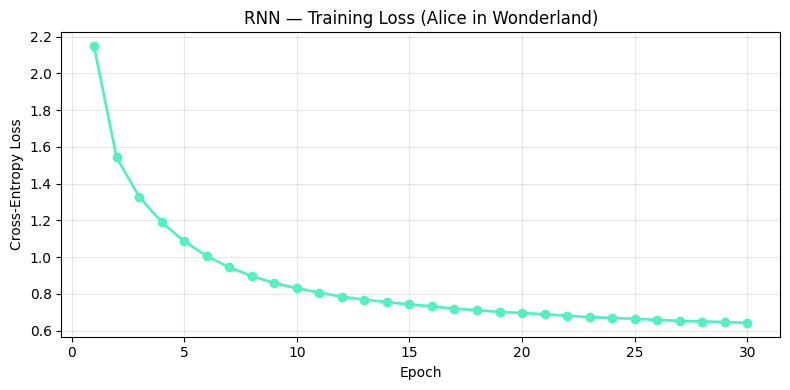

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, 'o-', color='#55efc4', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('RNN — Training Loss (Alice in Wonderland)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()